### RNN on IMDB
### LSTM on IMDB

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

---
#### 데이터 불러오기

In [2]:
vocab_size = 10000
max_len = 200

(train_input, train_target), (test_input, test_target) = imdb.load_data(num_words=vocab_size)

/opt/miniconda3/lib/python3.13/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


In [3]:
print(len(train_input), len(train_target))
print(len(test_input), len(test_target))
print(train_input[0][:10])
print(train_target[0])

25000 25000
25000 25000
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65]
1


In [4]:
train_input = pad_sequences(train_input, maxlen=max_len)
test_input = pad_sequences(test_input, maxlen=max_len)

train_target = np.array(train_target)
test_target = np.array(test_target)


In [5]:
train_input, val_input, train_target, val_target = train_test_split(
    train_input,
    train_target,
    test_size=0.2,
    random_state=42,
    stratify=train_target
)

In [6]:
train_input = torch.tensor(train_input, dtype=torch.long)
val_input = torch.tensor(val_input, dtype=torch.long)
test_input = torch.tensor(test_input, dtype=torch.long)

train_target = torch.tensor(train_target, dtype=torch.float32)
val_target = torch.tensor(val_target, dtype=torch.float32)
test_target = torch.tensor(test_target, dtype=torch.float32)

In [7]:
print(train_input.shape, train_target.shape)
print(val_input.shape, val_target.shape)
print(test_input.shape, test_target.shape)

torch.Size([20000, 200]) torch.Size([20000])
torch.Size([5000, 200]) torch.Size([5000])
torch.Size([25000, 200]) torch.Size([25000])


----
#### DataSet과 DataLoader 생성

In [8]:
batch_size = 32

train_dataset = TensorDataset(train_input, train_target)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(val_input, val_target)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

test_dataset = TensorDataset(test_input, test_target)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

----
#### RNN 모델 정의

In [9]:
class RNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size):
        super(RNNModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(embed_dim, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = self.embedding(x)
        output, hidden = self.rnn(x)
        x = hidden[-1]
        x = self.fc(x)
        return x.squeeze(1)

#### LSTM 모델 정의

In [10]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = self.embedding(x)
        output, (hidden, cell) = self.lstm(x)
        x = hidden[-1]
        x = self.fc(x)
        return x.squeeze(1)

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
print(device)

embed_dim = 32
hidden_size = 64

cpu


----
#### 학습 함수와 평가 함수

In [12]:
def train(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(train_loader)

In [13]:
def evaluate(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            total_loss += loss.item()

            predicted = (torch.sigmoid(outputs) >= 0.5).float()
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

    return total_loss / len(data_loader), correct / total

----
#### RNN 모델 훈련

In [14]:
rnn_model = RNNModel(vocab_size=vocab_size, embed_dim=embed_dim, hidden_size=hidden_size).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(rnn_model.parameters(), lr=0.001)

In [15]:
num_epochs = 10
rnn_train_loss_scores = []
rnn_val_loss_scores = []

for epoch in range(num_epochs):
    train_loss = train(rnn_model, train_loader, criterion, optimizer, device)
    val_loss, val_accuracy = evaluate(rnn_model, val_loader, criterion, device)
    rnn_train_loss_scores.append(train_loss)
    rnn_val_loss_scores.append(val_loss)
    print(f'RNN Epoch [{epoch + 1:>3} / {num_epochs}], Loss : {train_loss:.4f}, Val_loss : {val_loss:.4f}, Val_accuracy : {val_accuracy:.4f}')

RNN Epoch [  1 / 10], Loss : 0.6766, Val_loss : 0.6785, Val_accuracy : 0.5758
RNN Epoch [  2 / 10], Loss : 0.6360, Val_loss : 0.6195, Val_accuracy : 0.6660
RNN Epoch [  3 / 10], Loss : 0.5859, Val_loss : 0.6214, Val_accuracy : 0.6452
RNN Epoch [  4 / 10], Loss : 0.5216, Val_loss : 0.5509, Val_accuracy : 0.7414
RNN Epoch [  5 / 10], Loss : 0.4919, Val_loss : 0.5863, Val_accuracy : 0.7050
RNN Epoch [  6 / 10], Loss : 0.5027, Val_loss : 0.6224, Val_accuracy : 0.6650
RNN Epoch [  7 / 10], Loss : 0.4609, Val_loss : 0.5449, Val_accuracy : 0.7542
RNN Epoch [  8 / 10], Loss : 0.5254, Val_loss : 0.7696, Val_accuracy : 0.6260
RNN Epoch [  9 / 10], Loss : 0.5606, Val_loss : 0.6466, Val_accuracy : 0.6278
RNN Epoch [ 10 / 10], Loss : 0.5343, Val_loss : 0.5883, Val_accuracy : 0.7186


In [16]:
# RNN 훈련 평가
train_loss, train_accuracy = evaluate(rnn_model, train_loader, criterion, device)
print(f'RNN Train Loss : {train_loss:.4f}, Train Accuracy : {train_accuracy:.4f}')

# RNN 검증 평가
val_loss, val_accuracy = evaluate(rnn_model, val_loader, criterion, device)
print(f'RNN Val Loss : {val_loss:.4f}, Val Accuracy : {val_accuracy:.4f}')

# RNN 테스트 평가
test_loss, test_accuracy = evaluate(rnn_model, test_loader, criterion, device)
print(f'RNN Test Loss : {test_loss:.4f}, Test Accuracy : {test_accuracy:.4f}')

RNN Train Loss : 0.4337, Train Accuracy : 0.8046
RNN Val Loss : 0.5883, Val Accuracy : 0.7186
RNN Test Loss : 0.5767, Test Accuracy : 0.7225


----
#### LSTM 모델 훈련

In [17]:
lstm_model = LSTMModel(vocab_size=vocab_size, embed_dim=embed_dim, hidden_size=hidden_size).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(lstm_model.parameters(), lr=0.001)

In [18]:
num_epochs = 10
lstm_train_loss_scores = []
lstm_val_loss_scores = []

for epoch in range(num_epochs):
    train_loss = train(lstm_model, train_loader, criterion, optimizer, device)
    val_loss, val_accuracy = evaluate(lstm_model, val_loader, criterion, device)
    lstm_train_loss_scores.append(train_loss)
    lstm_val_loss_scores.append(val_loss)
    print(f'LSTM Epoch [{epoch + 1:>3} / {num_epochs}], Loss : {train_loss:.4f}, Val_loss : {val_loss:.4f}, Val_accuracy : {val_accuracy:.4f}')

LSTM Epoch [  1 / 10], Loss : 0.6318, Val_loss : 0.5420, Val_accuracy : 0.7274
LSTM Epoch [  2 / 10], Loss : 0.4989, Val_loss : 0.4836, Val_accuracy : 0.7802
LSTM Epoch [  3 / 10], Loss : 0.4069, Val_loss : 0.4335, Val_accuracy : 0.8172
LSTM Epoch [  4 / 10], Loss : 0.3683, Val_loss : 0.4076, Val_accuracy : 0.8186
LSTM Epoch [  5 / 10], Loss : 0.3321, Val_loss : 0.3821, Val_accuracy : 0.8420
LSTM Epoch [  6 / 10], Loss : 0.2680, Val_loss : 0.3686, Val_accuracy : 0.8508
LSTM Epoch [  7 / 10], Loss : 0.2326, Val_loss : 0.3650, Val_accuracy : 0.8590
LSTM Epoch [  8 / 10], Loss : 0.2245, Val_loss : 0.3647, Val_accuracy : 0.8432
LSTM Epoch [  9 / 10], Loss : 0.1929, Val_loss : 0.3742, Val_accuracy : 0.8602
LSTM Epoch [ 10 / 10], Loss : 0.1674, Val_loss : 0.3788, Val_accuracy : 0.8622


In [19]:
# LSTM 훈련 평가
train_loss, train_accuracy = evaluate(lstm_model, train_loader, criterion, device)
print(f'LSTM Train Loss : {train_loss:.4f}, Train Accuracy : {train_accuracy:.4f}')

# LSTM 검증 평가
val_loss, val_accuracy = evaluate(lstm_model, val_loader, criterion, device)
print(f'LSTM Val Loss : {val_loss:.4f}, Val Accuracy : {val_accuracy:.4f}')

# LSTM 테스트 평가
test_loss, test_accuracy = evaluate(lstm_model, test_loader, criterion, device)
print(f'LSTM Test Loss : {test_loss:.4f}, Test Accuracy : {test_accuracy:.4f}')

LSTM Train Loss : 0.1315, Train Accuracy : 0.9560
LSTM Val Loss : 0.3788, Val Accuracy : 0.8622
LSTM Test Loss : 0.3786, Test Accuracy : 0.8584


----
#### 학습 곡선 시각화

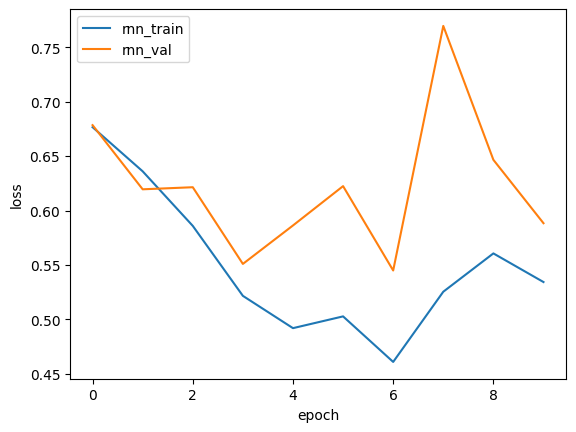

In [20]:
plt.plot(rnn_train_loss_scores)
plt.plot(rnn_val_loss_scores)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['rnn_train', 'rnn_val'])
plt.show()

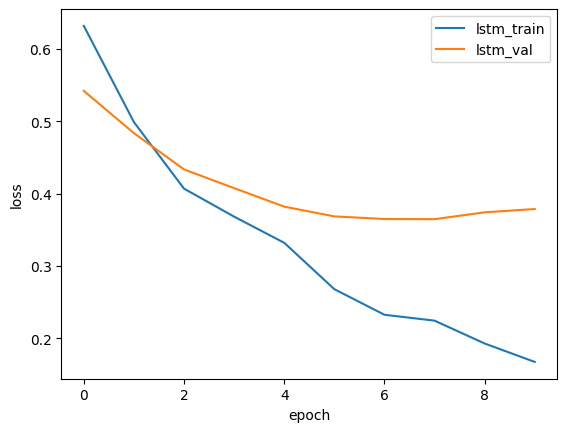

In [21]:
plt.plot(lstm_train_loss_scores)
plt.plot(lstm_val_loss_scores)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['lstm_train', 'lstm_val'])
plt.show()

----
#### 모델 저장하기

In [22]:
torch.save(rnn_model, '../Data/rnn_imdb.pth')
torch.save(lstm_model, '../Data/lstm_imdb.pth')

In [23]:
rnn_model1 = torch.load('../Data/rnn_imdb.pth', weights_only=False, map_location=device)
lstm_model1 = torch.load('../Data/lstm_imdb.pth', weights_only=False, map_location=device)
rnn_model1.eval()
lstm_model1.eval()

LSTMModel(
  (embedding): Embedding(10000, 32)
  (lstm): LSTM(32, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

----
#### 문장 하나 예측해보기

In [24]:
word_index = imdb.get_word_index()
index_to_word = {index + 3: word for word, index in word_index.items()}
index_to_word[0] = '<PAD>'
index_to_word[1] = '<START>'
index_to_word[2] = '<UNK>'
index_to_word[3] = '<UNUSED>'

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [25]:
sample = test_input[0]
print(sample.shape)

torch.Size([200])


In [26]:
def decode_review(sequence):
    return ' '.join([index_to_word.get(int(idx), '?') for idx in sequence if int(idx) > 2])

print(decode_review(sample))

please give this one a miss br br and the rest of the cast rendered terrible performances the show is flat flat flat br br i don't know how michael madison could have allowed this one on his plate he almost seemed to know this wasn't going to work out and his performance was quite so all you madison fans give this a miss


In [27]:
def predict_one(model, sequence, device):
    model.eval()
    with torch.no_grad():
        sequence = sequence.unsqueeze(0).to(device)
        output = model(sequence)
        prob = torch.sigmoid(output).item()
        label = '긍정' if prob >= 0.5 else '부정'
    return label, prob

In [28]:
predict_one(rnn_model1, sample, device)

('부정', 0.19804039597511292)

In [29]:
predict_one(lstm_model1, sample, device)

('긍정', 0.8115645051002502)